### Hospital Readmission Risk Prediction

\Importing necessary libraries

In [1]:
import pandas as pd       
import numpy as np        
import matplotlib.pyplot as plt 
import seaborn as sns     
import warnings
warnings.filterwarnings('ignore') 

plt.rcParams['figure.figsize'] = (10, 5)

\Loading the dataset

In [5]:
df = pd.read_csv(r'C:\NG\Hospital Readmission Risk Prediction\Data\Raw\hospital_readmission_dataset.csv')

\Data inspection

In [3]:
df.head()

,patient_id,patient_age,gender,marital_status,admission_type,department,diagnosis,secondary_diagnosis,blood_pressure,glucose_level,...,doctor_rating,followup_compliance_score,hospital_bill_amount,admission_date,discharge_date,followup_date,readmission_notice_sent,readmission_confirmed,final_readmission_reason,readmitted
0,PAT0000000,69,Female,Single,Elective,Orthopedics,Diabetes,NaN,119,227.0,...,10.0,43.0,₹125345,2024-11-12,2024-10-31,2026-11-20,No,Yes,NaN,1
1,PAT0000001,32,Male,Married,Emergency,Neurology,Asthma,Kidney Disease,122,100.0,...,1.0,94.0,26391.0,2024-12-28,2025-05-15,2026-11-14,Yes,Yes,Infection,1
2,PAT0000002,89,Male,Divorced,Urgent,General Medicine,Hypertension,Kidney Disease,90,237.0,...,4.0,18.0,NaN,2023-10-12,2023-06-25,2026-07-13,Yes,Yes,Medication Issue,1
3,PAT0000003,78,Male,Single,Elective,Pulmonology,Infection,NaN,127,NaN,...,10.0,12.0,61112.0,2025-07-27,2025-05-02,07-26-2026,No,No,NaN,1
4,PAT0000004,38,male,Single,Elective,Neurology,Asthma,Diabetes,92,74.0,...,4.0,NaN,NaN,2023-11-15,2026-01-29,2026-07-22,No,No,Medication Issue,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50500 entries, 0 to 50499
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 50500 non-null  str    
 1   patient_age                50500 non-null  int64  
 2   gender                     50500 non-null  str    
 3   marital_status             50500 non-null  str    
 4   admission_type             50500 non-null  str    
 5   department                 50500 non-null  str    
 6   diagnosis                  50500 non-null  str    
 7   secondary_diagnosis        37784 non-null  str    
 8   blood_pressure             50500 non-null  int64  
 9   glucose_level              42918 non-null  float64
 10  heart_rate                 50500 non-null  int64  
 11  bmi                        50500 non-null  float64
 12  previous_admissions        50500 non-null  int64  
 13  previous_emergency_visits  50500 non-null  int64  
 14  h

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
patient_age,50500.0,53.522139,21.677993,-5.0,35.00,53.00,71.00,180.0
blood_pressure,50500.0,129.274238,28.866958,80.0,104.00,129.00,154.00,179.0
glucose_level,42918.0,159.378303,52.029140,70.0,114.00,160.00,204.00,249.0
heart_rate,50500.0,84.803366,24.039114,50.0,67.00,85.00,102.00,500.0
bmi,50500.0,28.885968,6.713080,-20.0,23.43,28.97,34.48,40.0
previous_admissions,50500.0,4.568198,4.154271,0.0,2.00,4.00,7.00,100.0
previous_emergency_visits,50500.0,6.995446,4.325782,0.0,3.00,7.00,11.00,14.0
hospital_stay_days,50500.0,10.376337,12.533009,1.0,5.00,10.00,15.00,365.0
medication_count,50500.0,9.963069,5.462520,1.0,5.00,10.00,15.00,19.0
lab_test_count,50500.0,14.955267,8.346925,1.0,8.00,15.00,22.00,29.0


\Categorical Columns Unique Values

In [9]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("=== Categorical Columns — All Unique Values ===\n")

for col in categorical_cols:
    print(f"📌 {col} ({df[col].nunique()} unique values):")
    print("  ", df[col].value_counts().to_dict())
    print()

=== Categorical Columns — All Unique Values ===

📌 patient_id (50000 unique values):
   {'PAT0000147': 2, 'PAT0000199': 2, 'PAT0000262': 2, 'PAT0000292': 2, 'PAT0000314': 2, 'PAT0000508': 2, 'PAT0000659': 2, 'PAT0000708': 2, 'PAT0000725': 2, 'PAT0000821': 2, 'PAT0001030': 2, 'PAT0001118': 2, 'PAT0001122': 2, 'PAT0001164': 2, 'PAT0001390': 2, 'PAT0001414': 2, 'PAT0001640': 2, 'PAT0001812': 2, 'PAT0001822': 2, 'PAT0001900': 2, 'PAT0002008': 2, 'PAT0002189': 2, 'PAT0002354': 2, 'PAT0002530': 2, 'PAT0002729': 2, 'PAT0002741': 2, 'PAT0002791': 2, 'PAT0003016': 2, 'PAT0003104': 2, 'PAT0003211': 2, 'PAT0003221': 2, 'PAT0003697': 2, 'PAT0003732': 2, 'PAT0003850': 2, 'PAT0003862': 2, 'PAT0003918': 2, 'PAT0003928': 2, 'PAT0003940': 2, 'PAT0004064': 2, 'PAT0004070': 2, 'PAT0004086': 2, 'PAT0004144': 2, 'PAT0004168': 2, 'PAT0004469': 2, 'PAT0004772': 2, 'PAT0004813': 2, 'PAT0004817': 2, 'PAT0004892': 2, 'PAT0005071': 2, 'PAT0005222': 2, 'PAT0005395': 2, 'PAT0005503': 2, 'PAT0005545': 2, 'PAT000563

\ Target Variable Analysis

In [10]:
target_counts = df['readmitted'].value_counts()
target_pct    = df['readmitted'].value_counts(normalize=True) * 100

print("Count:")
print(target_counts)
print("\nPercentage:")
print(target_pct.round(2))

Count:
readmitted
1    47250
0     3250
Name: count, dtype: int64

Percentage:
readmitted
1    93.56
0     6.44
Name: proportion, dtype: float64


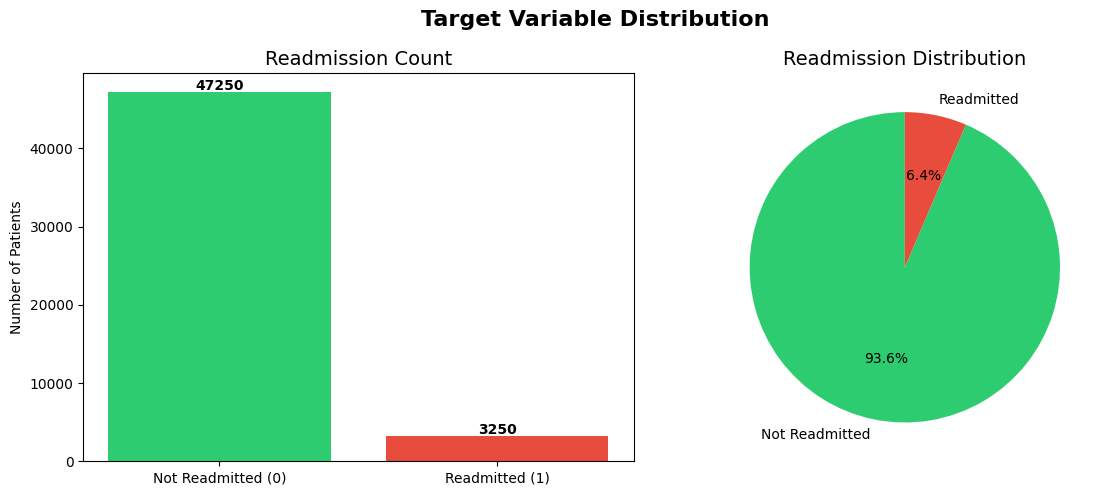


  CLASS IMBALANCE DETECTED!
Readmitted     : 47250 patients (93.6%)
Not Readmitted : 3250 patients (6.4%)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Not Readmitted (0)', 'Readmitted (1)'],
            target_counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Readmission Count', fontsize=14)
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values,
            labels=['Not Readmitted', 'Readmitted'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Readmission Distribution', fontsize=14)

plt.suptitle('Target Variable Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\NG\Hospital Readmission Risk Prediction\Data\Raw\reports/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n  CLASS IMBALANCE DETECTED!")
print(f"Readmitted     : {target_counts[1]} patients ({target_pct[1]:.1f}%)")
print(f"Not Readmitted : {target_counts[0]} patients ({target_pct[0]:.1f}%)")

\Identify Leakage Columns

In [13]:
print("=== DATA LEAKAGE ANALYSIS ===\n")

leakage_columns = [
    'readmission_notice_sent',
    'readmission_confirmed',
    'final_readmission_reason'
]

leakage_reasons = {
    'readmission_notice_sent' : (
        "This notice is sent BECAUSE the patient was readmitted. "
        "We cannot know this BEFORE the readmission event happens."
    ),
    'readmission_confirmed'   : (
        "This directly confirms readmission — it IS the event we are predicting. "
        "Using it as a feature would give 100% accuracy but zero real-world value."
    ),
    'final_readmission_reason': (
        "The reason is known ONLY AFTER the patient is readmitted. "
        "Also notice: it is missing for all non-readmitted patients (19.79% NaN)."
    )
}

for col in leakage_columns:
    print(f" Column       : {col}")
    print(f"   Unique Values: {df[col].value_counts().to_dict()}")
    print(f"   Missing %    : {df[col].isna().sum() / len(df) * 100:.2f}%")
    print(f"   Why Leakage  : {leakage_reasons[col]}")
    print()

print(" These 3 columns will be DROPPED before any model training.")

=== DATA LEAKAGE ANALYSIS ===

 Column       : readmission_notice_sent
   Unique Values: {'Yes': 25279, 'No': 25221}
   Missing %    : 0.00%
   Why Leakage  : This notice is sent BECAUSE the patient was readmitted. We cannot know this BEFORE the readmission event happens.

 Column       : readmission_confirmed
   Unique Values: {'Yes': 25293, 'No': 25207}
   Missing %    : 0.00%
   Why Leakage  : This directly confirms readmission — it IS the event we are predicting. Using it as a feature would give 100% accuracy but zero real-world value.

 Column       : final_readmission_reason
   Unique Values: {'Infection': 10187, 'Medication Issue': 10154, 'Followup Missed': 10128, 'Complication': 10036}
   Missing %    : 19.79%
   Why Leakage  : The reason is known ONLY AFTER the patient is readmitted. Also notice: it is missing for all non-readmitted patients (19.79% NaN).

 These 3 columns will be DROPPED before any model training.


\ Business Relevance Summary

In [14]:
business_context = {
    'patient_age'              : 'Older patients have weaker immunity — higher readmission risk',
    'gender'                   : 'Gender-based health patterns differ — hormonal, lifestyle factors',
    'marital_status'           : 'Married patients have better home care support',
    'admission_type'           : 'Emergency admissions indicate critical condition',
    'department'               : 'Cardiology/Neurology patients are higher risk',
    'diagnosis'                : 'Chronic diseases like Diabetes have high recurrence',
    'secondary_diagnosis'      : 'Multiple diseases = more complex treatment',
    'blood_pressure'           : 'High BP indicates cardiovascular stress',
    'glucose_level'            : 'Uncontrolled glucose = diabetic complications',
    'heart_rate'               : 'Abnormal heart rate = cardiac instability',
    'bmi'                      : 'Obesity increases surgical and recovery risk',
    'previous_admissions'      : 'Frequent past admissions = chronic/recurring condition',
    'previous_emergency_visits': 'Past ER visits = history of acute episodes',
    'hospital_stay_days'       : 'Longer stay = more severe illness',
    'insurance_type'           : 'Insurance affects quality of post-discharge care',
    'medication_count'         : 'More medications = complex condition, compliance risk',
    'lab_test_count'           : 'More tests = severity of investigation needed',
    'doctor_rating'            : 'Low rating may indicate suboptimal care',
    'followup_compliance_score': 'Low score = patient skipping checkups = high risk',
    'hospital_bill_amount'     : 'High bill = complex treatment = higher risk patient',
    'admission_date'           : 'Used to derive season, month trends',
    'discharge_date'           : 'Used to calculate length of stay',
    'followup_date'            : 'Used to calculate days to follow-up after discharge'
}

print("=== BUSINESS RELEVANCE OF EACH FEATURE ===\n")
for feature, reason in business_context.items():
    print(f" {feature:<30} → {reason}")

=== BUSINESS RELEVANCE OF EACH FEATURE ===

 patient_age                    → Older patients have weaker immunity — higher readmission risk
 gender                         → Gender-based health patterns differ — hormonal, lifestyle factors
 marital_status                 → Married patients have better home care support
 admission_type                 → Emergency admissions indicate critical condition
 department                     → Cardiology/Neurology patients are higher risk
 diagnosis                      → Chronic diseases like Diabetes have high recurrence
 secondary_diagnosis            → Multiple diseases = more complex treatment
 blood_pressure                 → High BP indicates cardiovascular stress
 glucose_level                  → Uncontrolled glucose = diabetic complications
 heart_rate                     → Abnormal heart rate = cardiac instability
 bmi                            → Obesity increases surgical and recovery risk
 previous_admissions            → Frequent p

\Saving Summary Report

In [ ]:
report = f"""
=== HOSPITAL READMISSION — DATA UNDERSTANDING REPORT ===

Dataset Shape     : {df.shape[0]} rows x {df.shape[1]} columns
Total Features    : {df.shape[1] - 1} (excluding target)
Target Variable   : readmitted (0 = No, 1 = Yes)

TARGET DISTRIBUTION:
  Readmitted     : {df['readmitted'].sum()} ({df['readmitted'].mean()*100:.1f}%)
  Not Readmitted : {(df['readmitted']==0).sum()} ({(df['readmitted']==0).mean()*100:.1f}%)
  Severe class imbalance detected

MISSING VALUES:
  secondary_diagnosis       : 25.18%
  glucose_level             : 15.01%
  doctor_rating             : 15.01%
  followup_compliance_score : 14.94%
  hospital_bill_amount      : 12.87%
  final_readmission_reason  : 19.79% (LEAKAGE — will be dropped)

DATA QUALITY ISSUES SPOTTED:
  1. gender — inconsistent values (Male/male/M/MALE)
  2. hospital_bill_amount — currency symbol (₹) mixed with plain numbers
  3. followup_date — mixed date formats (YYYY-MM-DD and MM-DD-YYYY)
  4. 3 leakage columns identified

LEAKAGE COLUMNS (to be dropped):
  - readmission_notice_sent
  - readmission_confirmed
  - final_readmission_reason
"""

with open(r'C:\NG\Hospital Readmission Risk Prediction\reports/01_data_understanding_report.txt', 'w',encoding='utf-8') as f:
    f.write(report)

print(report)


=== HOSPITAL READMISSION — DATA UNDERSTANDING REPORT ===

Dataset Shape     : 50500 rows x 28 columns
Total Features    : 27 (excluding target)
Target Variable   : readmitted (0 = No, 1 = Yes)

TARGET DISTRIBUTION:
  Readmitted     : 47250 (93.6%)
  Not Readmitted : 3250 (6.4%)
  Severe class imbalance detected

MISSING VALUES:
  secondary_diagnosis       : 25.18%
  glucose_level             : 15.01%
  doctor_rating             : 15.01%
  followup_compliance_score : 14.94%
  hospital_bill_amount      : 12.87%
  final_readmission_reason  : 19.79% (LEAKAGE — will be dropped)

DATA QUALITY ISSUES SPOTTED:
  1. gender — inconsistent values (Male/male/M/MALE)
  2. hospital_bill_amount — currency symbol (₹) mixed with plain numbers
  3. followup_date — mixed date formats (YYYY-MM-DD and MM-DD-YYYY)
  4. 3 leakage columns identified

LEAKAGE COLUMNS (to be dropped):
  - readmission_notice_sent
  - readmission_confirmed
  - final_readmission_reason

 Report saved to reports/01_data_understand